# Лабораторная работа №2



команда:

Аббясов Радислам 367038

Егорова Варвара 408575

Ташкинова Татьяна 413084

## 1. Импорт библиотек


In [ ]:
import os
import re
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, iirnotch
from scipy.integrate import trapezoid

## 2. Подготовка данных



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
muscle_folders = ['на кисти', 'предплечье', 'плечо']

In [ ]:
from pathlib import Path

# Путь к папке второй лабы
DATA_DIR = Path('/content/drive/MyDrive/нейро2')

print('Папка с данными:', DATA_DIR)

print('\nСодержимое:')

for item in sorted(DATA_DIR.iterdir()):
    print('-' if item.is_dir() else '-', item.name)

Папка с данными: /content/drive/MyDrive/нейро2

Содержимое:
- .DS_Store
- на кисти
- плечо
- предплечье


## 3. Поиск OpenBCI-файлов

Для второй лабораторной используются файлы OpenBCI в формате `.txt`. Название родительской папки считается зоной регистрации, а название файла — движением.

In [ ]:
def normalize_action_name(file_name):
    name = Path(file_name).stem
    name = re.sub(r'\s*\(\d+\)$', '', name)
    name = name.replace('_', ' ')
    return name.strip()


def build_openbci_registry(data_dir):
    data_dir = Path(data_dir)
    rows = []

    for file_path in data_dir.rglob('*.txt'):
        if '__MACOSX' in str(file_path) or file_path.name.startswith('._'):
            continue

        parts = file_path.relative_to(data_dir).parts
        if len(parts) < 2:
            continue

        zone = parts[-2]
        action = normalize_action_name(file_path.name)

        rows.append({
            'zone': zone,
            'action': action,
            'file_name': file_path.name,
            'file_path': str(file_path)
        })

    registry = pd.DataFrame(rows)

    if len(registry) > 0:
        registry = registry.sort_values(['zone', 'action']).reset_index(drop=True)

    return registry


openbci_files = build_openbci_registry(DATA_DIR)

print('Найдено OpenBCI-файлов:', len(openbci_files))
display(openbci_files)

Найдено OpenBCI-файлов: 16


,zone,action,file_name,file_path
0,на кисти,кисть вращение кулак,кисть_вращение_кулак (1).txt,/content/drive/MyDrive/нейро2/на кисти/кисть_в...
1,на кисти,кисть пианино,кисть_пианино (1).txt,/content/drive/MyDrive/нейро2/на кисти/кисть_п...
2,на кисти,кисть поднять,кисть_поднять.txt,/content/drive/MyDrive/нейро2/на кисти/кисть_п...
3,на кисти,кисть сгибать палец,кисть_сгибать палец.txt,/content/drive/MyDrive/нейро2/на кисти/кисть_с...
4,на кисти,кисть сжатие в кулак,кисть_сжатие_в_кулак.txt,/content/drive/MyDrive/нейро2/на кисти/кисть_с...
5,плечо,плечо вращение,плечо_вращение.txt,/content/drive/MyDrive/нейро2/плечо/плечо_вращ...
6,плечо,плечо гусь,плечо_гусь.txt,/content/drive/MyDrive/нейро2/плечо/плечо_гусь...
7,плечо,плечо паровозик,плечо_паровозик.txt,/content/drive/MyDrive/нейро2/плечо/плечо_паро...
8,плечо,плечо сгибание вертикально,плечо_сгибание_вертикально.txt,/content/drive/MyDrive/нейро2/плечо/плечо_сгиб...
9,плечо,плечо сгибание горизонтально,плечо_сгибание_горизонтально.txt,/content/drive/MyDrive/нейро2/плечо/плечо_сгиб...


## 4. Чтение OpenBCI-файла

Файлы OpenBCI содержат служебные строки, начинающиеся с `%`, а затем таблицу с несколькими каналами. В данной работе для анализа используется канал `EXG Channel 0`.

In [ ]:
def detect_sample_rate(file_path, default_fs=250):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            if 'Sample Rate' in line:
                match = re.search(r'(\d+(?:\.\d+)?)\s*Hz', line)
                if match:
                    return float(match.group(1))
    return float(default_fs)


def read_openbci_emg(file_path, channel='EXG Channel 0'):
    file_path = Path(file_path)
    fs = detect_sample_rate(file_path)

    data = pd.read_csv(file_path, comment='%', sep=',', engine='python')
    data.columns = data.columns.str.strip()

    if channel not in data.columns:
        available = [col for col in data.columns if 'EXG Channel' in col]
        raise ValueError(f'Канал {channel} не найден. Доступные EXG-каналы: {available}')

    emg = pd.to_numeric(data[channel], errors='coerce').to_numpy()
    valid = np.isfinite(emg)
    emg = emg[valid]

    time = np.arange(len(emg)) / fs

    return time, emg, fs


sample_row = openbci_files.iloc[0]
t, x, fs = read_openbci_emg(sample_row['file_path'], channel='EXG Channel 0')

print('Пример:', sample_row['zone'], '|', sample_row['action'])
print('Файл:', sample_row['file_name'])
print('Количество точек:', len(x))
print('Частота дискретизации:', round(fs, 2), 'Гц')
print('Длительность:', round(t[-1] - t[0], 2), 'с')

Пример: на кисти | кисть вращение кулак
Файл: кисть_вращение_кулак (1).txt
Количество точек: 4255
Частота дискретизации: 250.0 Гц
Длительность: 17.02 с


## 5. Функции предобработки ЭМГ

Для ЭМГ-сигналов OpenBCI используется последовательность обработки: обрезка начала записи, подавление выбросов, полосовая фильтрация, notch-фильтр 50 Гц, выпрямление и сглаживание для получения огибающей.

In [ ]:
def cut_recording_start(time, signal_values, seconds=2):
    time = np.asarray(time)
    signal_values = np.asarray(signal_values)

    mask = time >= seconds
    cropped_time = time[mask] - time[mask][0]
    cropped_signal = signal_values[mask]

    return cropped_time, cropped_signal


def remove_outliers_mad(signal_values, limit=6):
    signal_values = np.asarray(signal_values)
    median_value = np.median(signal_values)
    mad = np.median(np.abs(signal_values - median_value))

    if mad == 0:
        return signal_values.copy()

    robust_z = 0.6745 * (signal_values - median_value) / mad
    outliers = np.abs(robust_z) > limit
    corrected = signal_values.copy()

    if np.any(outliers) and np.any(~outliers):
        corrected[outliers] = np.interp(
            np.flatnonzero(outliers),
            np.flatnonzero(~outliers),
            signal_values[~outliers]
        )

    return corrected


def butter_bandpass_filter(signal_values, sample_rate, low=20, high=120, order=4):
    nyquist = sample_rate / 2
    high = min(high, nyquist * 0.95)

    b, a = butter(N=order, Wn=[low / nyquist, high / nyquist], btype='bandpass')
    return filtfilt(b, a, signal_values)


def remove_powerline_noise(signal_values, sample_rate, noise_freq=50, quality_factor=30):
    if noise_freq >= sample_rate / 2:
        return signal_values

    b, a = iirnotch(w0=noise_freq, Q=quality_factor, fs=sample_rate)
    return filtfilt(b, a, signal_values)


def get_emg_envelope(rectified_signal, sample_rate, cutoff=8, order=4):
    nyquist = sample_rate / 2
    cutoff = min(cutoff, nyquist * 0.95)

    b, a = butter(N=order, Wn=cutoff / nyquist, btype='lowpass')
    return filtfilt(b, a, rectified_signal)


def process_openbci_emg(time, emg, fs, crop_start=2, band_low=20, band_high=120, envelope_cutoff=8, use_notch=True):
    time_cut, emg_cut = cut_recording_start(time, emg, seconds=crop_start)

    centered = emg_cut - np.median(emg_cut)
    corrected = remove_outliers_mad(centered, limit=6)

    filtered = butter_bandpass_filter(corrected, sample_rate=fs, low=band_low, high=band_high, order=4)

    if use_notch:
        filtered = remove_powerline_noise(filtered, fs, noise_freq=50)

    rectified = np.abs(filtered)
    envelope = get_emg_envelope(rectified, fs, cutoff=envelope_cutoff)

    return {
        'time': time_cut,
        'raw': emg_cut,
        'centered': centered,
        'corrected': corrected,
        'filtered': filtered,
        'rectified': rectified,
        'envelope': envelope,
        'fs': fs
    }

## 6. Визуальная проверка этапов обработки

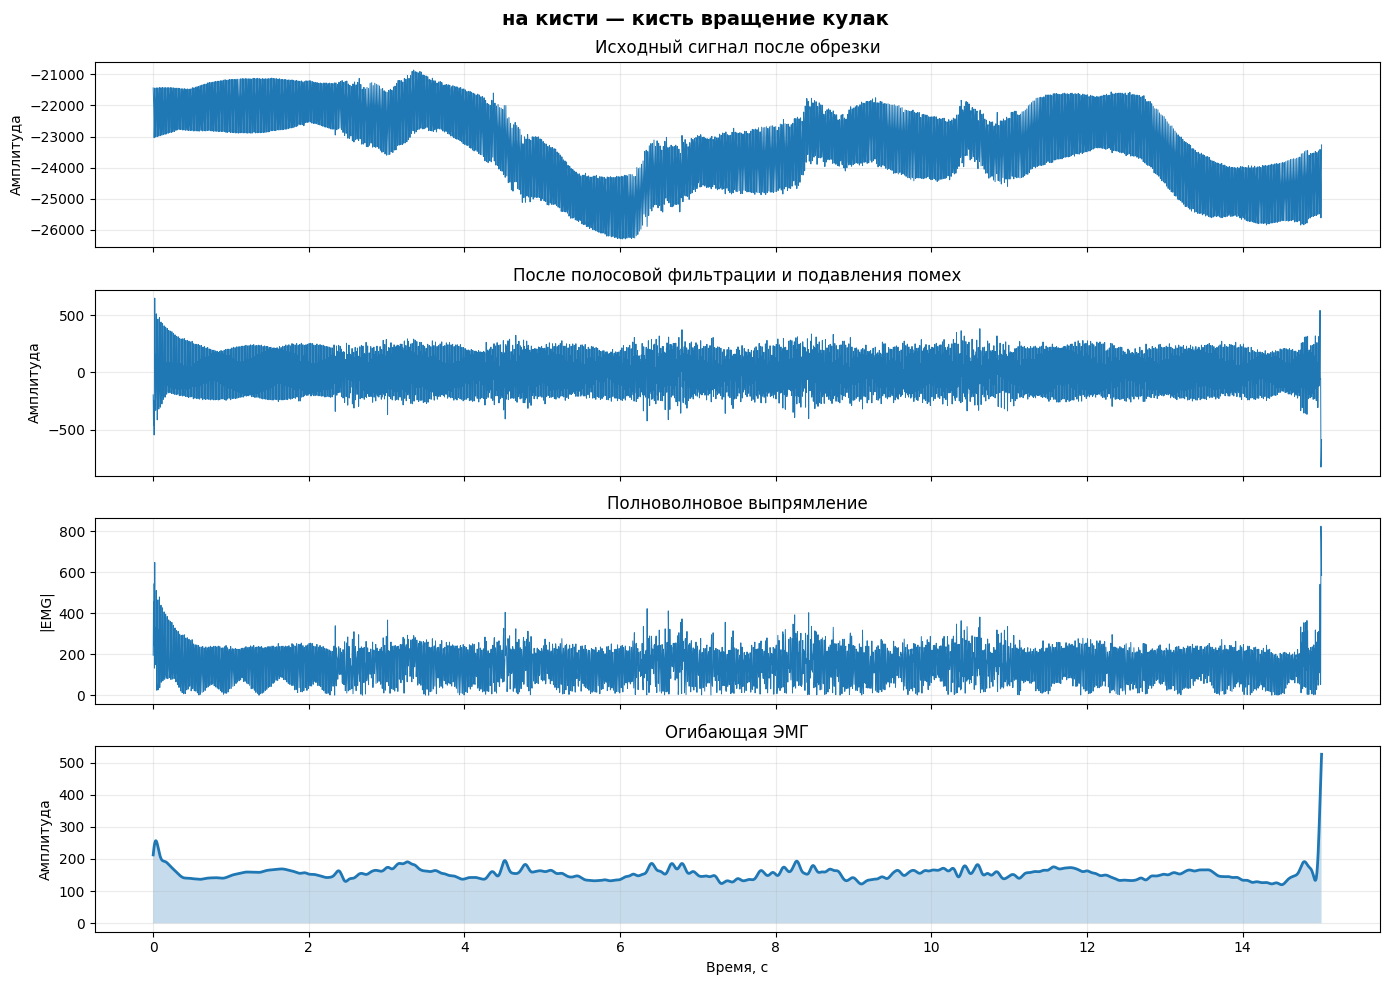

In [ ]:
def plot_processing_steps(processed, title=''):
    time = processed['time']
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(time, processed['raw'], linewidth=0.7)
    axes[0].set_title('Исходный сигнал после обрезки')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(alpha=0.25)

    axes[1].plot(time, processed['filtered'], linewidth=0.7)
    axes[1].set_title('После полосовой фильтрации и подавления помех')
    axes[1].set_ylabel('Амплитуда')
    axes[1].grid(alpha=0.25)

    axes[2].plot(time, processed['rectified'], linewidth=0.7)
    axes[2].set_title('Полноволновое выпрямление')
    axes[2].set_ylabel('|EMG|')
    axes[2].grid(alpha=0.25)

    axes[3].plot(time, processed['envelope'], linewidth=2)
    axes[3].fill_between(time, 0, processed['envelope'], alpha=0.25)
    axes[3].set_title('Огибающая ЭМГ')
    axes[3].set_xlabel('Время, с')
    axes[3].set_ylabel('Амплитуда')
    axes[3].grid(alpha=0.25)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

processed_sample = process_openbci_emg(t, x, fs)
plot_processing_steps(processed_sample, f"{sample_row['zone']} — {sample_row['action']}")

## 7. Расчёт параметров ЭМГ

Для каждого движения считаются: `max_amplitude`, `mean_amplitude`, `iemg`, `rms`, `median_amplitude`, `peak_to_average`.

In [ ]:
def calculate_emg_features(processed_signal):
    time = processed_signal['time']
    envelope = processed_signal['envelope']

    peak_amplitude = np.max(envelope)
    average_amplitude = np.mean(envelope)
    integrated_emg = trapezoid(envelope, time)
    rms_value = np.sqrt(np.mean(envelope ** 2))
    median_value = np.median(envelope)

    peak_ratio = peak_amplitude / average_amplitude if average_amplitude > 0 else 0

    return {
        'max_amplitude': peak_amplitude,
        'mean_amplitude': average_amplitude,
        'iemg': integrated_emg,
        'rms': rms_value,
        'median_amplitude': median_value,
        'peak_to_average': peak_ratio
    }

## 8. Обработка всех файлов

In [ ]:
EMG_CHANNEL = 'EXG Channel 0'

processed_signals = {}
metric_rows = []
errors = []

for _, row in openbci_files.iterrows():
    try:
        time, emg, fs = read_openbci_emg(row['file_path'], channel=EMG_CHANNEL)
        processed = process_openbci_emg(time, emg, fs)
        metrics = calculate_emg_features(processed)

        key = f"{row['zone']} | {row['action']}"
        processed_signals[key] = processed

        metric_rows.append({
            'zone': row['zone'],
            'action': row['action'],
            'file_name': row['file_name'],
            'fs': fs,
            **metrics
        })

    except Exception as error:
        errors.append((row['file_path'], str(error)))

results = pd.DataFrame(metric_rows)

print('Успешно обработано файлов:', len(results))
print('Ошибок:', len(errors))
display(results.round(4))

if errors:
    print('Файлы с ошибками:')
    for file_path, error_text in errors:
        print(file_path, '->', error_text)

Успешно обработано файлов: 16
Ошибок: 0


,zone,action,file_name,fs,max_amplitude,mean_amplitude,iemg,rms,median_amplitude,peak_to_average
0,на кисти,кисть вращение кулак,кисть_вращение_кулак (1).txt,250.0,525.7128,154.7779,2323.2865,156.2244,154.3666,3.3966
1,на кисти,кисть пианино,кисть_пианино (1).txt,250.0,361.8223,156.0811,2728.0855,157.1040,154.1120,2.3182
2,на кисти,кисть поднять,кисть_поднять.txt,250.0,540.8784,167.8202,3006.9459,169.2298,165.6420,3.2230
3,на кисти,кисть сгибать палец,кисть_сгибать палец.txt,250.0,418.2263,152.9899,2818.1282,154.4577,148.5338,2.7337
4,на кисти,кисть сжатие в кулак,кисть_сжатие_в_кулак.txt,250.0,406.6026,194.5352,3635.9968,198.8109,182.3860,2.0901
5,плечо,плечо вращение,плечо_вращение.txt,250.0,291.8726,40.8230,979.7315,51.6185,28.8663,7.1497
6,плечо,плечо гусь,плечо_гусь.txt,250.0,233.1690,47.3494,1083.4001,58.8705,31.9159,4.9244
7,плечо,плечо паровозик,плечо_паровозик.txt,250.0,207.4167,51.2633,1085.4100,63.0414,34.3193,4.0461
8,плечо,плечо сгибание вертикально,плечо_сгибание_вертикально.txt,250.0,201.7371,43.5169,1013.9735,55.0482,27.9451,4.6358
9,плечо,плечо сгибание горизонтально,плечо_сгибание_горизонтально.txt,250.0,407.9601,67.6388,1481.1977,90.3521,39.6604,6.0314


## 9. Выбор наиболее выраженного движения для каждой зоны

Итоговый рейтинг считается по трём параметрам: `rms`, `iemg`, `max_amplitude`. Значения нормируются внутри каждой зоны регистрации.

In [ ]:
def add_zone_scores(df):
    df = df.copy()
    score_columns = ['rms', 'iemg', 'max_amplitude']

    for column in score_columns:
        norm_column = column + '_norm'
        df[norm_column] = df.groupby('zone')[column].transform(
            lambda values: (values - values.min()) / (values.max() - values.min())
            if values.max() != values.min()
            else 0
        )

    df['total_score'] = df[['rms_norm', 'iemg_norm', 'max_amplitude_norm']].mean(axis=1)
    return df

ranked = add_zone_scores(results)
ranked = ranked.sort_values(['zone', 'total_score'], ascending=[True, False]).reset_index(drop=True)

display(ranked[['zone', 'action', 'max_amplitude', 'mean_amplitude', 'rms', 'iemg', 'median_amplitude', 'peak_to_average', 'total_score']].round(4))

best_by_zone = ranked.loc[ranked.groupby('zone')['total_score'].idxmax()].sort_values('zone')

print('Лучшее движение для каждой зоны регистрации:')
display(best_by_zone[['zone', 'action', 'total_score', 'rms', 'iemg', 'max_amplitude']].round(4))

,zone,action,max_amplitude,mean_amplitude,rms,iemg,median_amplitude,peak_to_average,total_score
0,на кисти,кисть сжатие в кулак,406.6026,194.5352,198.8109,3635.9968,182.3860,2.0901,0.7500
1,на кисти,кисть поднять,540.8784,167.8202,169.2298,3006.9459,165.6420,3.2230,0.6180
2,на кисти,кисть вращение кулак,525.7128,154.7779,156.2244,2323.2865,154.3666,3.3966,0.3184
3,на кисти,кисть сгибать палец,418.2263,152.9899,154.4577,2818.1282,148.5338,2.7337,0.2307
4,на кисти,кисть пианино,361.8223,156.0811,157.1040,2728.0855,154.1120,2.3182,0.1227
5,плечо,плечо сгибание горизонтально,407.9601,67.6388,90.3521,1481.1977,39.6604,6.0314,1.0000
6,плечо,плечо гусь,233.1690,47.3494,58.8705,1083.4001,31.9159,4.9244,0.1821
7,плечо,плечо паровозик,207.4167,51.2633,63.0414,1085.4100,34.3193,4.0461,0.1777
8,плечо,плечо вращение,291.8726,40.8230,51.6185,979.7315,28.8663,7.1497,0.1457
9,плечо,плечо сгибание вертикально,201.7371,43.5169,55.0482,1013.9735,27.9451,4.6358,0.0523


Лучшее движение для каждой зоны регистрации:


,zone,action,total_score,rms,iemg,max_amplitude
0,на кисти,кисть сжатие в кулак,0.75,198.8109,3635.9968,406.6026
5,плечо,плечо сгибание горизонтально,1.00,90.3521,1481.1977,407.9601
10,предплечье,предплечье кулак 2,1.00,221.5965,4190.2104,1281.3158


## 10. Визуализация лучших движений

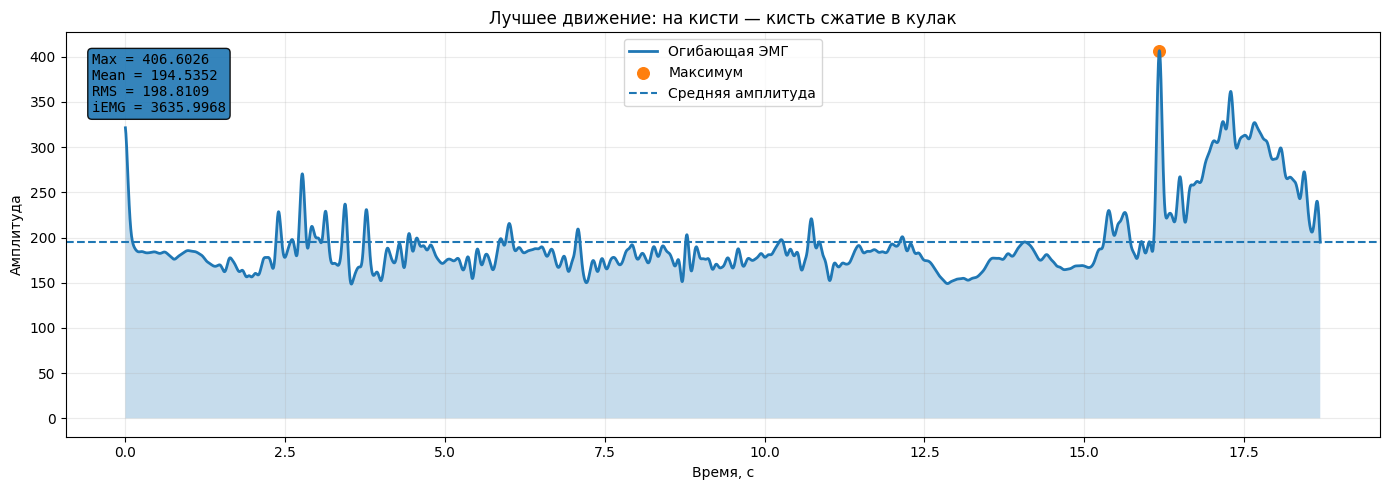

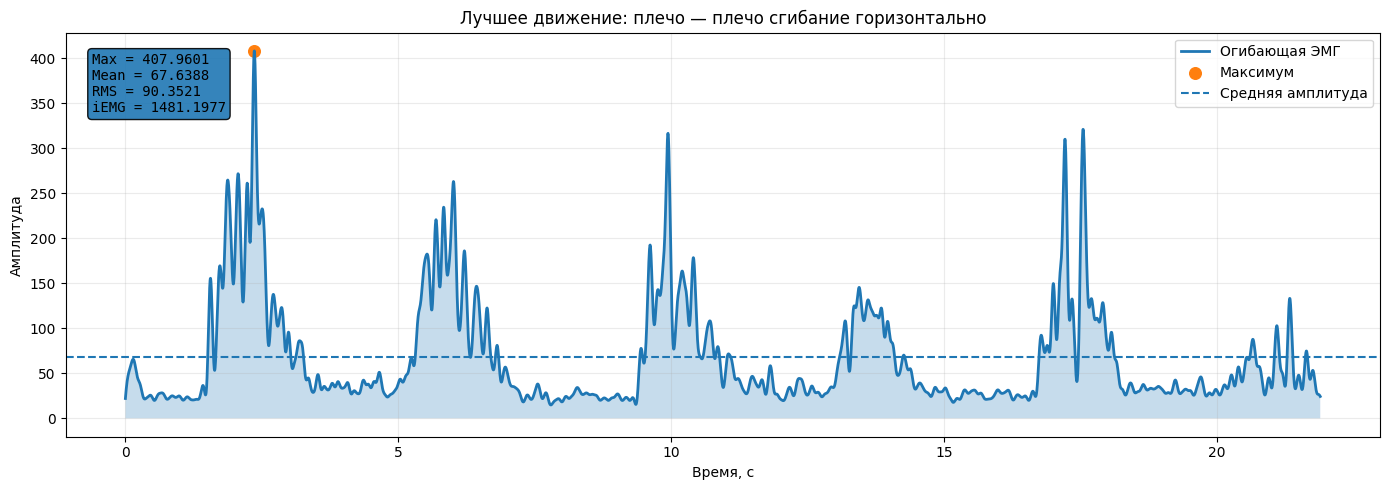

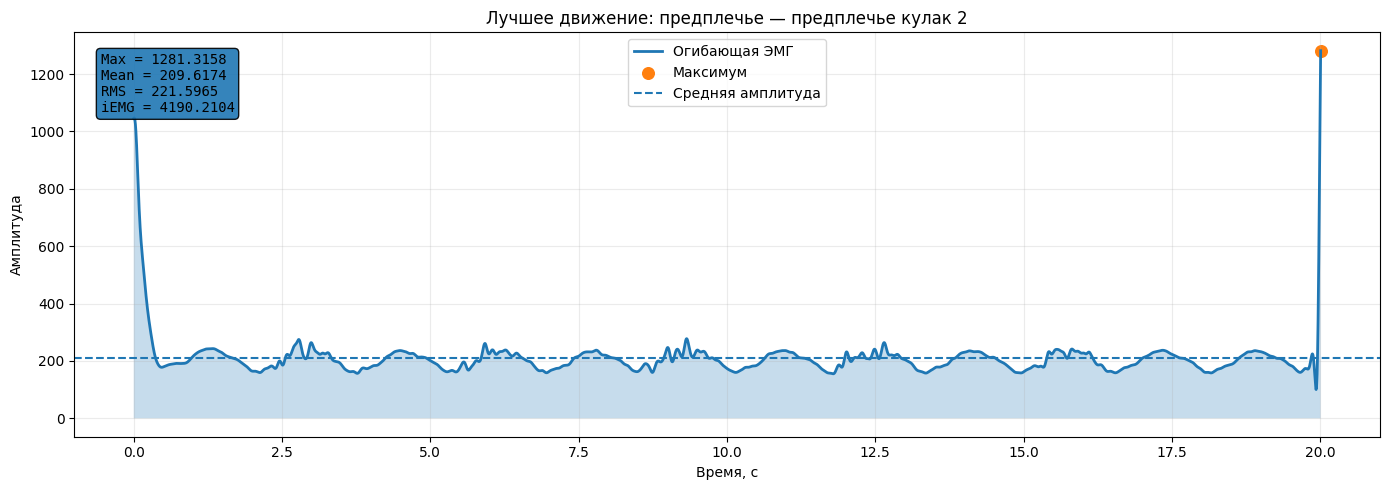

In [ ]:
def plot_best_signal(row):
    key = f"{row['zone']} | {row['action']}"
    processed = processed_signals[key]

    time = processed['time']
    envelope = processed['envelope']

    plt.figure(figsize=(14, 5))

    plt.plot(
        time,
        envelope,
        linewidth=2,
        label='Огибающая ЭМГ'
    )

    plt.fill_between(
        time,
        0,
        envelope,
        alpha=0.25
    )

    max_index = np.argmax(envelope)

    plt.scatter(
        time[max_index],
        envelope[max_index],
        s=70,
        label='Максимум'
    )

    plt.axhline(
        row['mean_amplitude'],
        linestyle='--',
        linewidth=1.5,
        label='Средняя амплитуда'
    )

    text = (
        f"Max = {row['max_amplitude']:.4f}\n"
        f"Mean = {row['mean_amplitude']:.4f}\n"
        f"RMS = {row['rms']:.4f}\n"
        f"iEMG = {row['iemg']:.4f}"
    )

    plt.text(
        0.02,
        0.95,
        text,
        transform=plt.gca().transAxes,
        va='top',
        family='monospace',
        bbox=dict(boxstyle='round', alpha=0.9)
    )

    plt.title(
        f"Лучшее движение: {row['zone']} — {row['action']}"
    )

    plt.xlabel('Время, с')
    plt.ylabel('Амплитуда')

    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for _, best_row in best_by_zone.iterrows():
    plot_best_signal(best_row)

## 11. Сравнение параметров по зонам

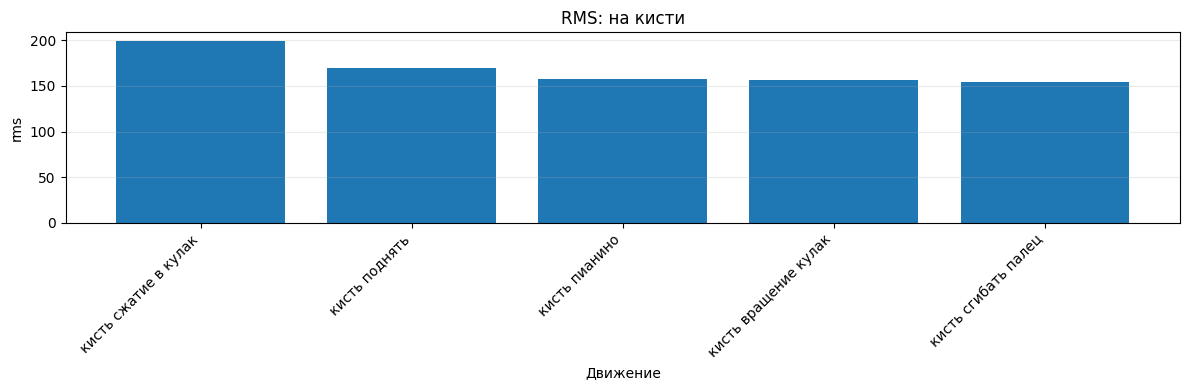

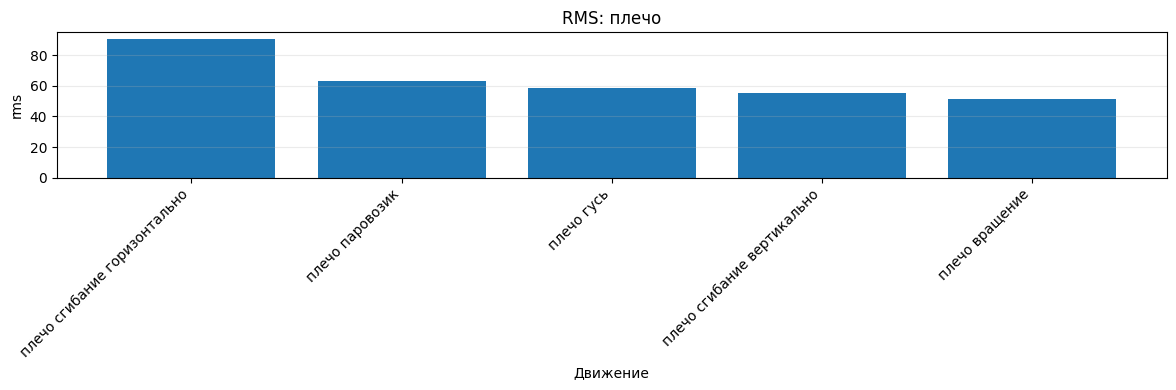

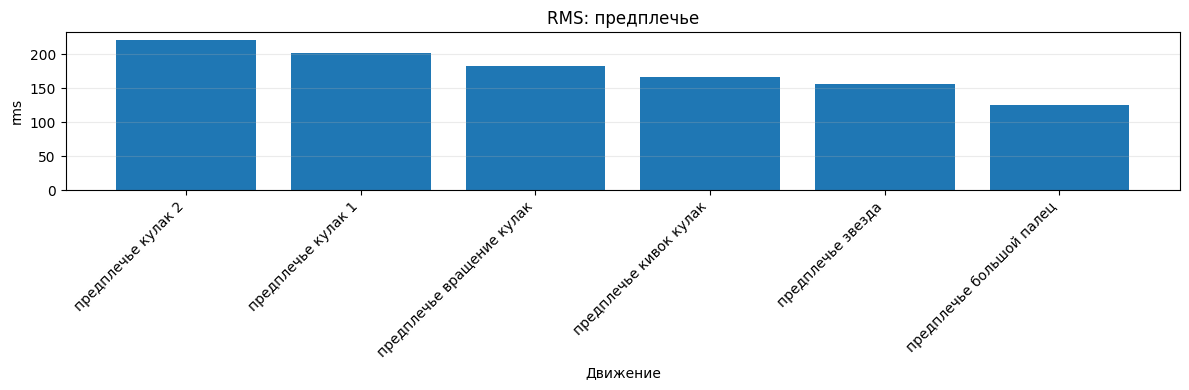

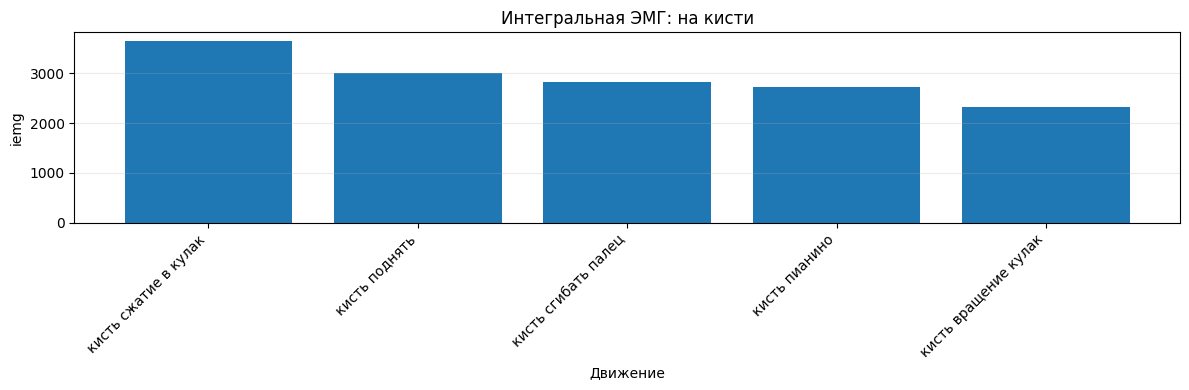

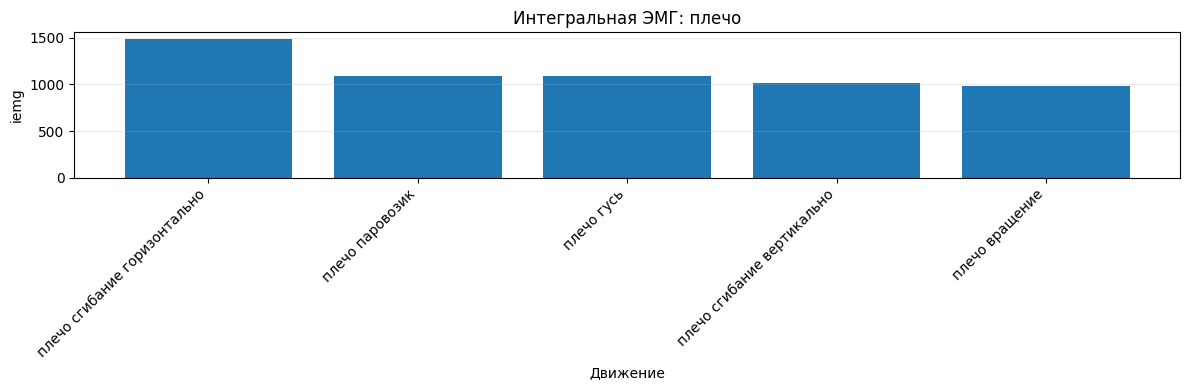

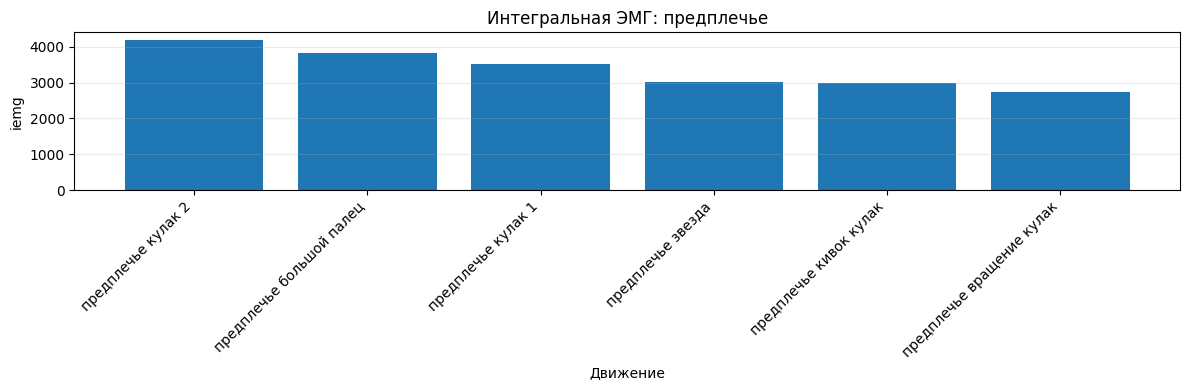

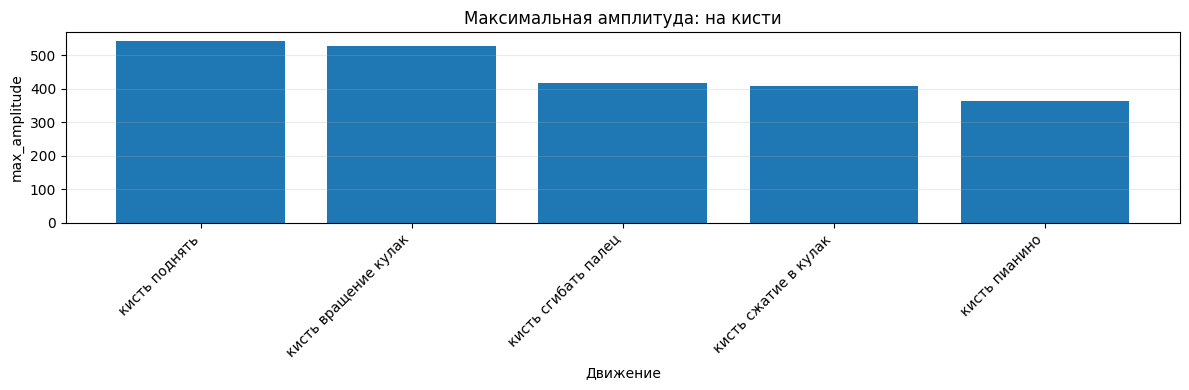

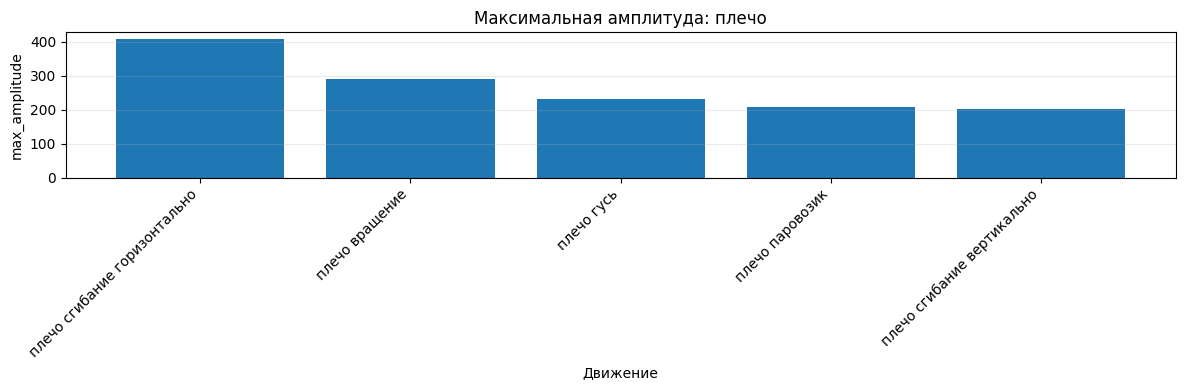

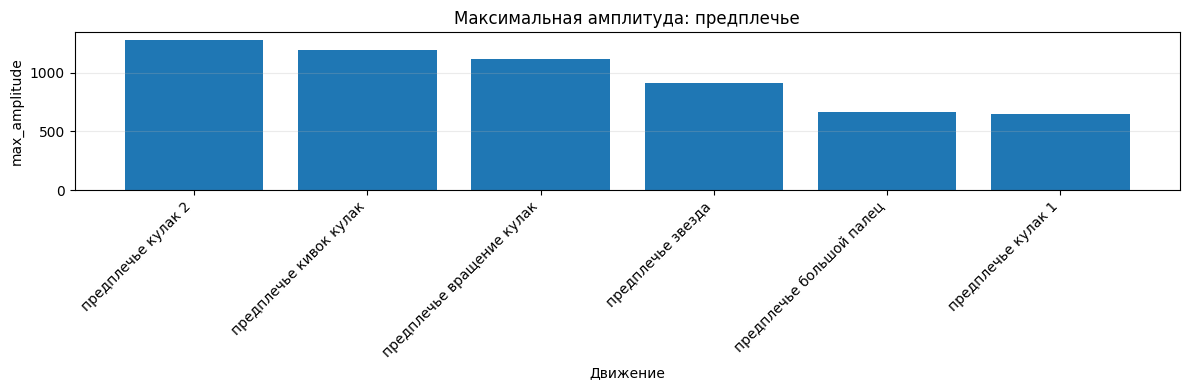

In [ ]:
def plot_metric_by_zone(df, metric, title):
    zones = sorted(df['zone'].unique())

    for zone in zones:
        subset = df[df['zone'] == zone].sort_values(metric, ascending=False)

        plt.figure(figsize=(12, 4))
        plt.bar(subset['action'], subset[metric])
        plt.title(f'{title}: {zone}')
        plt.xlabel('Движение')
        plt.ylabel(metric)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()

plot_metric_by_zone(ranked, 'rms', 'RMS')
plot_metric_by_zone(ranked, 'iemg', 'Интегральная ЭМГ')
plot_metric_by_zone(ranked, 'max_amplitude', 'Максимальная амплитуда')

## Общий вывод


В ходе лабораторной работы были обработаны ЭМГ-сигналы OpenBCI. Всего найдено 16 файлов, успешно обработано 16 файлов.
Для каждого сигнала была выполнена предобработка: обрезка начального участка, подавление выбросов, полосовая фильтрация, notch-фильтрация 50 Гц, полноволновое выпрямление и построение огибающей ЭМГ.
Для оценки мышечной активности были рассчитаны максимальная амплитуда, средняя амплитуда, RMS, iEMG, медианная амплитуда и отношение максимума к среднему значению.

Наиболее выраженные движения по зонам регистрации:
- на кисти: кисть сжатие в кулак (total_score = 0.750, RMS = 198.8109, iEMG = 3635.9968, Max = 406.6026)
- плечо: плечо сгибание горизонтально (total_score = 1.000, RMS = 90.3521, iEMG = 1481.1977, Max = 407.9601)
- предплечье: предплечье кулак 2 (total_score = 1.000, RMS = 221.5965, iEMG = 4190.2104, Max = 1281.3158)

Таким образом, обработка OpenBCI-данных позволила выделить огибающую ЭМГ, сравнить движения между собой и определить действия с наиболее сильной электрической активностью мышц.